RETAIL DEMAND FORECASTING USING DYNAMIC PROGRAMMING

Please upload your retail demand CSV dataset.
Select the CSV file from your computer.



Saving retail_demand_dataset.csv to retail_demand_dataset.csv

File uploaded successfully:
retail_demand_dataset.csv

Loading dataset...
Dataset loaded successfully.

ORIGINAL DATASET
         Date  Demand  Promotion  DayOfWeek  Month
0  2026-01-01  106.48       0.00   Thursday      1
1  2026-01-02  108.06       0.00     Friday      1
2  2026-01-03  124.74       0.00   Saturday      1
3  2026-01-04  125.71       0.00     Sunday      1
4  2026-01-05   96.65       0.00     Monday      1
5  2026-01-06  116.24      15.87    Tuesday      1
6  2026-01-07  143.60      27.99  Wednesday      1
7  2026-01-08  128.68      15.31   Thursday      1
8  2026-01-09  139.64      29.55     Friday      1
9  2026-01-10  145.34      17.73   Saturday      1

Number of records: 180

Columns:
['Date', 'Demand', 'Promotion', 'DayOfWeek', 'Month']

PREPROCESSED DATA
         Date  Demand  DayOfWeek  Month  Previous7DayMean  Previous7DayStd
0  2026-01-01  106.48   Thursday      1               NaN        17.39342

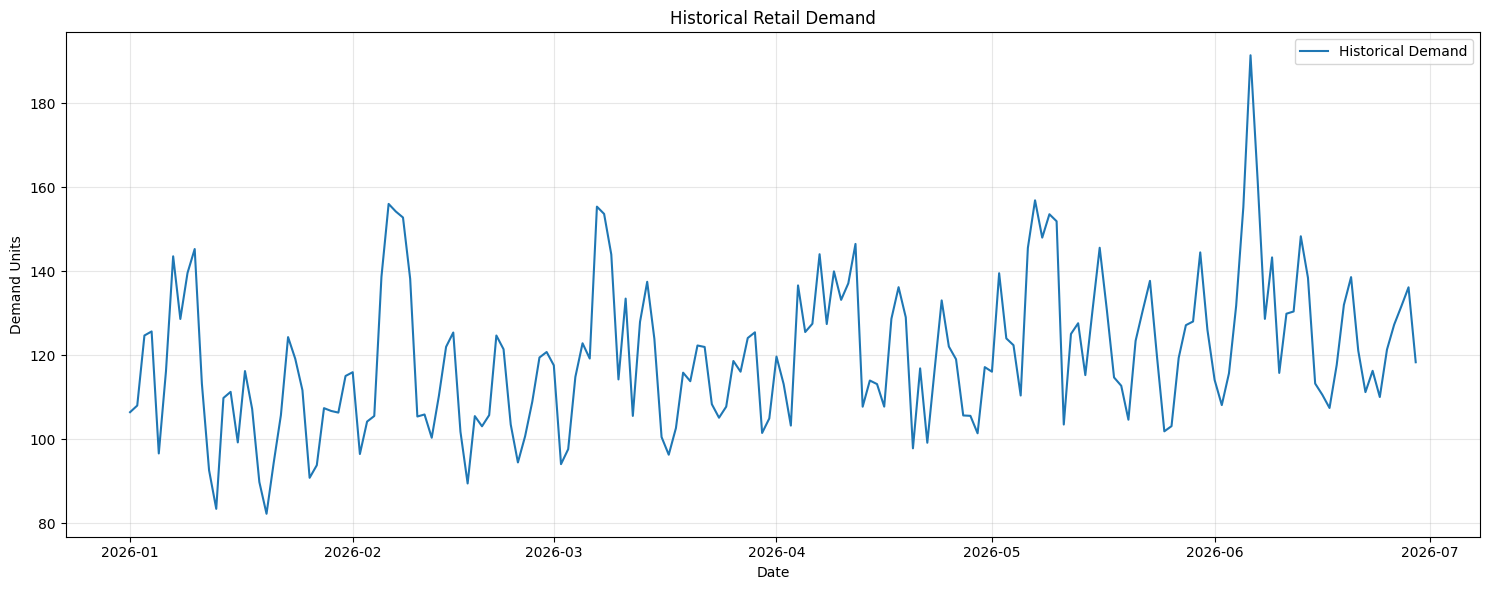

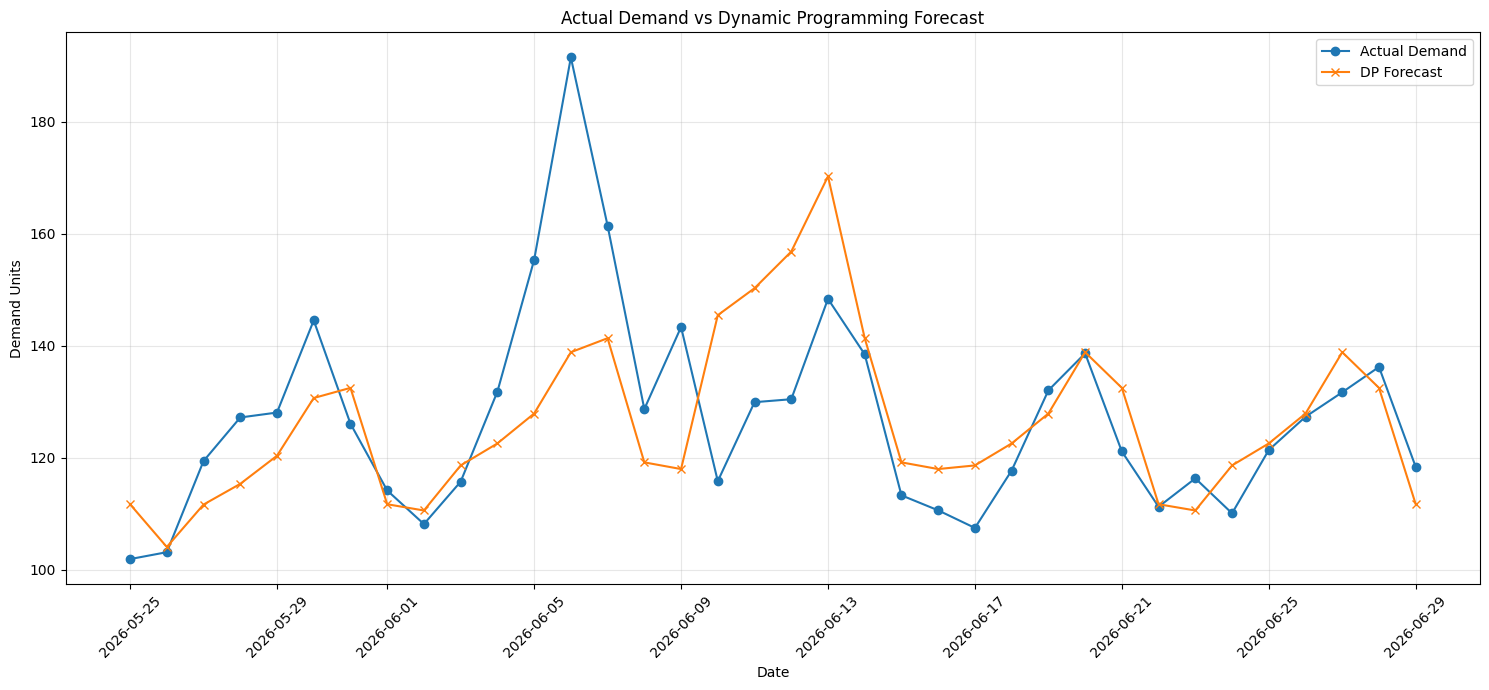

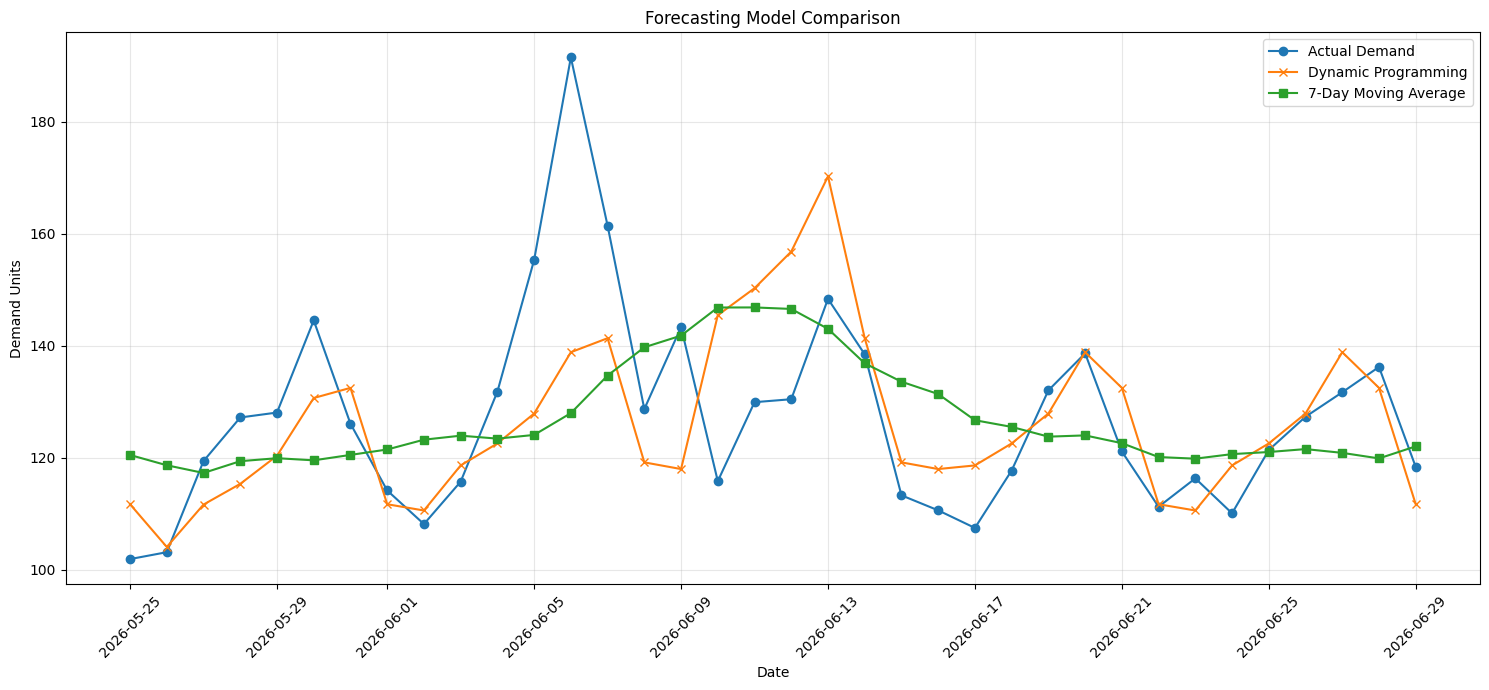

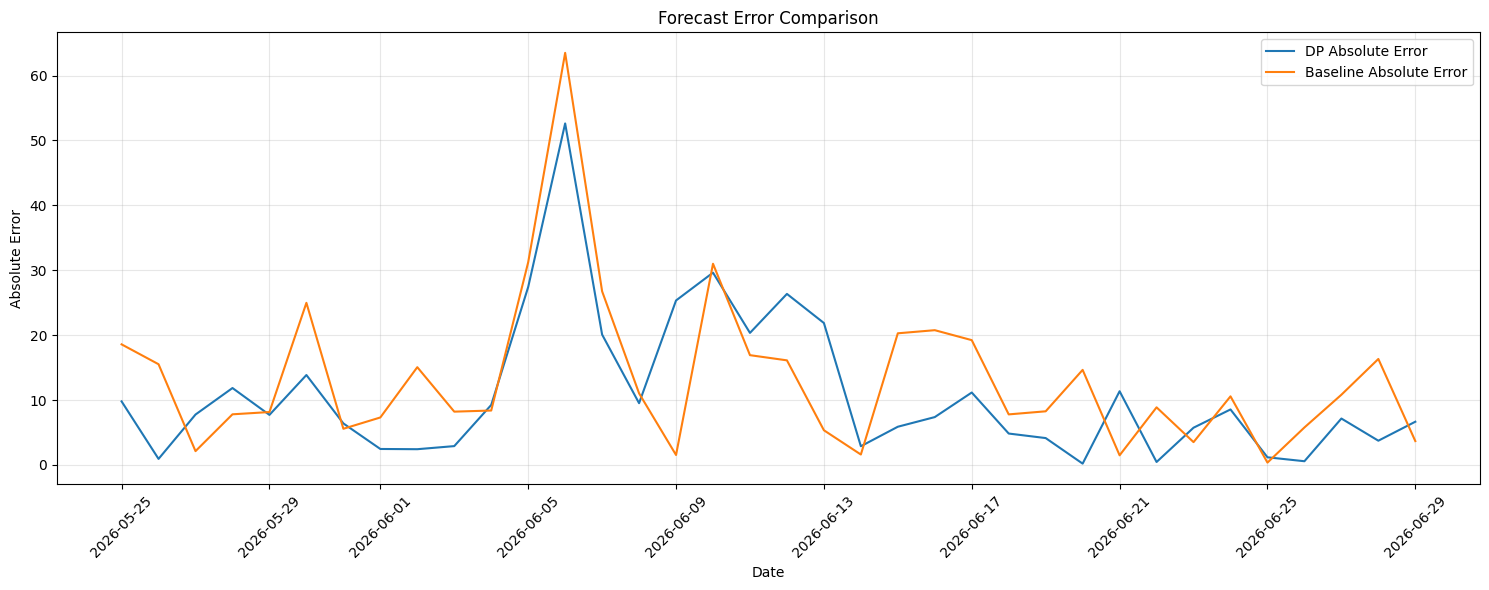

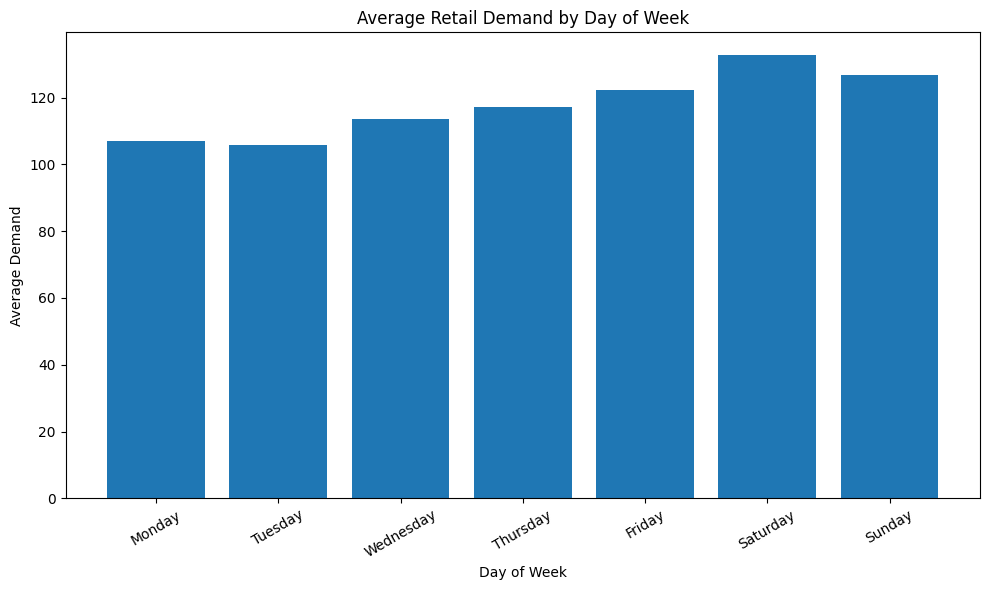

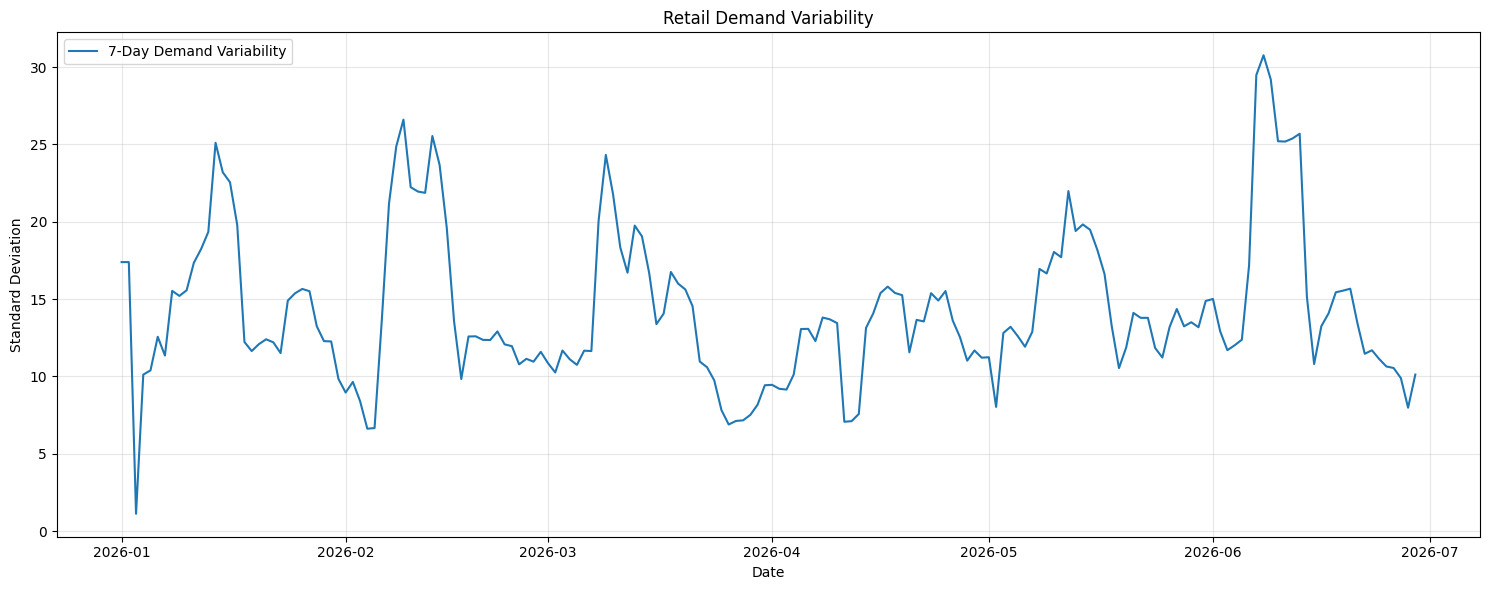


NEXT 14 DAYS DEMAND FORECAST
         Date  Forecast  State     State_Name  Seasonal_Factor  \
0  2026-06-30    110.59      4  Above Average           0.8959   
1  2026-07-01    118.64      4  Above Average           0.9610   
2  2026-07-02    122.57      4  Above Average           0.9928   
3  2026-07-03    127.90      4  Above Average           1.0361   
4  2026-07-04    138.85      4  Above Average           1.1248   
5  2026-07-05    132.49      4  Above Average           1.0732   
6  2026-07-06    111.71      4  Above Average           0.9049   
7  2026-07-07    110.59      4  Above Average           0.8959   
8  2026-07-08    118.64      4  Above Average           0.9610   
9  2026-07-09    122.57      4  Above Average           0.9928   
10 2026-07-10    127.90      4  Above Average           1.0361   
11 2026-07-11    138.85      4  Above Average           1.1248   
12 2026-07-12    132.49      4  Above Average           1.0732   
13 2026-07-13    111.71      4  Above Average 

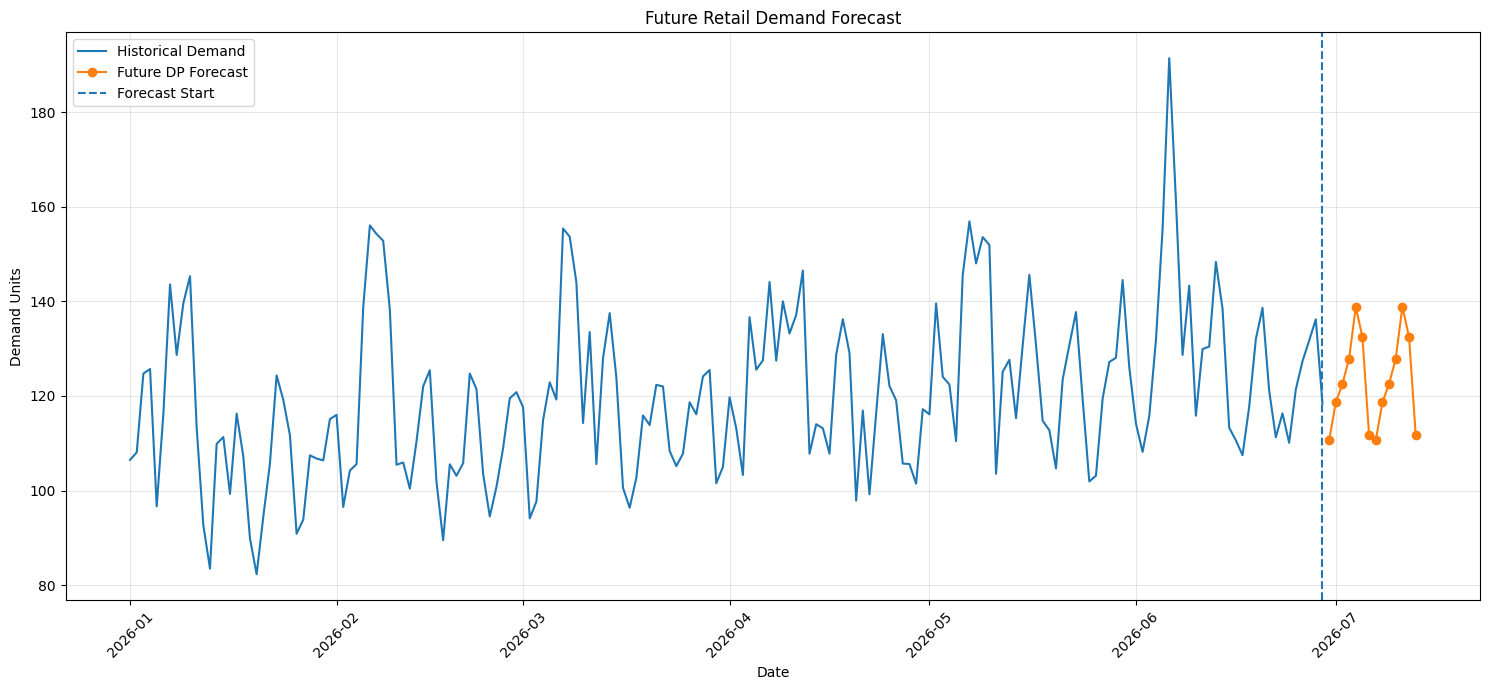


SUPPLY-CHAIN INVENTORY RECOMMENDATION
Average future demand : 123.25 units
Recent demand variation : 18.32 units
Safety stock : 30.23 units
Recommended inventory : 153.48 units

COMPUTATIONAL COMPLEXITY
Number of training observations (n): 144
Number of forecast states (k): 7

Time Complexity: O(n × k²)
Approximate DP state comparisons: 7056

Space Complexity: O(n × k)
DP table dimensions: 144 × 7

FINAL PROJECT SUMMARY

The Retail Demand Forecasting system:

1. Accepts a CSV dataset through Google Colab upload.

2. Cleans and preprocesses historical retail demand data.

3. Identifies weekly seasonal demand patterns.

4. Measures recent demand variability.

5. Generates multiple forecast states.

6. Uses Dynamic Programming to find an optimized sequence
   of forecast states.

7. Uses optimal substructure and overlapping subproblems.

8. Uses backtracking to reconstruct the optimal state sequence.

9. Generates test forecasts without using the current
   future actual demand.

10. Eva

In [2]:
# ================================================================
# RETAIL DEMAND FORECASTING OPTIMIZATION USING DYNAMIC PROGRAMMING
# ================================================================
#
# Google Colab Version
#
# The program asks the user to upload the CSV dataset.
# No manual file-path configuration is required.
#
# ================================================================


# ================================================================
# 1. IMPORT LIBRARIES
# ================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import timedelta

# Google Colab file upload
from google.colab import files


# ================================================================
# 2. CONFIGURATION
# ================================================================

NUM_STATES = 7

TRAIN_RATIO = 0.80

LAMBDA = 0.15

SAFETY_FACTOR = 1.65

FUTURE_DAYS = 14


# ================================================================
# 3. UPLOAD DATASET
# ================================================================

print("=" * 75)
print("RETAIL DEMAND FORECASTING USING DYNAMIC PROGRAMMING")
print("=" * 75)

print("\nPlease upload your retail demand CSV dataset.")
print("Select the CSV file from your computer.\n")

uploaded = files.upload()


# ================================================================
# 4. CHECK UPLOADED FILE
# ================================================================

if len(uploaded) == 0:

    raise ValueError(
        "No file was uploaded. Please run the cell again "
        "and upload a CSV dataset."
    )


# Get the first uploaded filename
DATA_FILE = list(uploaded.keys())[0]


print("\nFile uploaded successfully:")
print(DATA_FILE)


# ================================================================
# 5. CHECK FILE TYPE
# ================================================================

if not DATA_FILE.lower().endswith(".csv"):

    raise ValueError(
        "Please upload a CSV file."
    )


# ================================================================
# 6. LOAD DATASET
# ================================================================

print("\nLoading dataset...")

data = pd.read_csv(
    DATA_FILE
)

print("Dataset loaded successfully.")


# ================================================================
# 7. DISPLAY ORIGINAL DATA
# ================================================================

print("\n" + "=" * 75)
print("ORIGINAL DATASET")
print("=" * 75)

print(
    data.head(10)
)

print(
    "\nNumber of records:",
    len(data)
)

print(
    "\nColumns:"
)

print(
    data.columns.tolist()
)


# ================================================================
# 8. CHECK REQUIRED COLUMNS
# ================================================================

required_columns = [
    "Date",
    "Demand"
]

missing_columns = [
    column
    for column in required_columns
    if column not in data.columns
]


if len(missing_columns) > 0:

    raise ValueError(
        "\nThe uploaded CSV is missing these required columns:\n"
        + str(missing_columns)
        + "\n\nYour CSV must contain at least:\n"
        "Date,Demand"
    )


# ================================================================
# 9. DATA PREPROCESSING
# ================================================================

def preprocess_data(df):

    df = df.copy()

    # ------------------------------------------------------------
    # Convert Date
    # ------------------------------------------------------------

    df["Date"] = pd.to_datetime(
        df["Date"],
        errors="coerce"
    )

    # ------------------------------------------------------------
    # Convert Demand to numeric
    # ------------------------------------------------------------

    df["Demand"] = pd.to_numeric(
        df["Demand"],
        errors="coerce"
    )

    # ------------------------------------------------------------
    # Remove invalid dates
    # ------------------------------------------------------------

    df = df.dropna(
        subset=["Date"]
    )

    # ------------------------------------------------------------
    # Sort chronologically
    # ------------------------------------------------------------

    df = (
        df.sort_values("Date")
        .reset_index(drop=True)
    )

    # ------------------------------------------------------------
    # Remove duplicate dates
    # ------------------------------------------------------------

    df = (
        df.drop_duplicates(
            subset=["Date"],
            keep="first"
        )
        .reset_index(drop=True)
    )

    # ------------------------------------------------------------
    # Handle missing demand
    # ------------------------------------------------------------

    df["Demand"] = (
        df["Demand"]
        .interpolate(
            method="linear"
        )
    )

    # ------------------------------------------------------------
    # Fill any remaining missing values
    # ------------------------------------------------------------

    df["Demand"] = (
        df["Demand"]
        .fillna(
            df["Demand"].median()
        )
    )

    # ------------------------------------------------------------
    # Demand cannot be negative
    # ------------------------------------------------------------

    df["Demand"] = (
        df["Demand"]
        .clip(lower=0)
    )

    # ------------------------------------------------------------
    # Date features
    # ------------------------------------------------------------

    df["DayOfWeekNumber"] = (
        df["Date"].dt.dayofweek
    )

    df["DayOfWeek"] = (
        df["Date"].dt.day_name()
    )

    df["Month"] = (
        df["Date"].dt.month
    )

    # ------------------------------------------------------------
    # Previous 7-day mean
    #
    # shift(1) prevents the current day's actual demand
    # from being used.
    # ------------------------------------------------------------

    df["Previous7DayMean"] = (
        df["Demand"]
        .shift(1)
        .rolling(
            window=7,
            min_periods=1
        )
        .mean()
    )

    # ------------------------------------------------------------
    # Previous 7-day standard deviation
    # ------------------------------------------------------------

    df["Previous7DayStd"] = (
        df["Demand"]
        .shift(1)
        .rolling(
            window=7,
            min_periods=2
        )
        .std()
    )

    # Fill initial missing standard deviation values
    overall_std = (
        df["Demand"].std()
    )

    if pd.isna(overall_std):
        overall_std = 0

    df["Previous7DayStd"] = (
        df["Previous7DayStd"]
        .fillna(overall_std)
    )

    return df


data = preprocess_data(
    data
)


# ================================================================
# 10. CHECK WHETHER ENOUGH DATA EXISTS
# ================================================================

if len(data) < 20:

    raise ValueError(
        "The dataset contains too few observations. "
        "Please upload a dataset with at least 20 records."
    )


# ================================================================
# 11. DISPLAY PREPROCESSED DATA
# ================================================================

print("\n" + "=" * 75)
print("PREPROCESSED DATA")
print("=" * 75)

print(
    data[
        [
            "Date",
            "Demand",
            "DayOfWeek",
            "Month",
            "Previous7DayMean",
            "Previous7DayStd"
        ]
    ].head(15)
)


# ================================================================
# 12. DEMAND STATISTICS
# ================================================================

print("\n" + "=" * 75)
print("DEMAND STATISTICS")
print("=" * 75)

print(
    data["Demand"].describe()
)


# ================================================================
# 13. TRAIN-TEST SPLIT
# ================================================================

train_size = int(
    len(data) * TRAIN_RATIO
)

train_data = (
    data.iloc[:train_size]
    .copy()
    .reset_index(drop=True)
)

test_data = (
    data.iloc[train_size:]
    .copy()
    .reset_index(drop=True)
)

train_demand = (
    train_data["Demand"]
    .values
)

test_demand = (
    test_data["Demand"]
    .values
)


print("\n" + "=" * 75)
print("TRAIN / TEST SPLIT")
print("=" * 75)

print(
    "Total observations :",
    len(data)
)

print(
    "Training records   :",
    len(train_data)
)

print(
    "Testing records    :",
    len(test_data)
)

print(
    "Training period    :",
    train_data["Date"].iloc[0].date(),
    "to",
    train_data["Date"].iloc[-1].date()
)

print(
    "Testing period     :",
    test_data["Date"].iloc[0].date(),
    "to",
    test_data["Date"].iloc[-1].date()
)


# ================================================================
# 14. CALCULATE SEASONAL FACTORS
# ================================================================

def calculate_seasonal_factors(
    training_data
):

    overall_mean = (
        training_data["Demand"]
        .mean()
    )

    weekday_means = (
        training_data
        .groupby(
            "DayOfWeekNumber"
        )["Demand"]
        .mean()
    )

    seasonal_factors = {}

    for day in range(7):

        if day in weekday_means.index:

            factor = (
                weekday_means[day]
                / overall_mean
            )

        else:

            factor = 1.0

        seasonal_factors[day] = factor

    return seasonal_factors


seasonal_factors = (
    calculate_seasonal_factors(
        train_data
    )
)


# ================================================================
# 15. DISPLAY SEASONAL FACTORS
# ================================================================

day_names = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]


print("\n" + "=" * 75)
print("WEEKLY SEASONAL FACTORS")
print("=" * 75)

for day in range(7):

    print(
        f"{day_names[day]:10s} : "
        f"{seasonal_factors[day]:.4f}"
    )


# ================================================================
# 16. GENERATE FORECAST STATES
# ================================================================

def generate_forecast_states(
    training_demand,
    num_states
):

    percentiles = np.linspace(
        5,
        95,
        num_states
    )

    states = np.percentile(
        training_demand,
        percentiles
    )

    states = np.round(
        states,
        2
    )

    # Remove duplicate states if demand values are similar
    states = np.unique(
        states
    )

    return states


forecast_states = (
    generate_forecast_states(
        train_demand,
        NUM_STATES
    )
)


# ================================================================
# 17. DISPLAY FORECAST STATES
# ================================================================

state_names = [
    "Very Low",
    "Low",
    "Below Average",
    "Average",
    "Above Average",
    "High",
    "Very High"
]


print("\n" + "=" * 75)
print("FORECAST STATES")
print("=" * 75)

for i, state in enumerate(
    forecast_states
):

    if i < len(state_names):

        name = state_names[i]

    else:

        name = f"State {i}"

    print(
        f"State {i} "
        f"({name:13s}) : "
        f"{state:.2f} units"
    )


# ================================================================
# 18. CREATE BASELINE FORECAST
# ================================================================

def create_baseline_forecast(
    df,
    seasonal_factors
):

    result = df.copy()

    forecasts = []

    for i in range(
        len(result)
    ):

        # --------------------------------------------------------
        # Use previous observations only
        # --------------------------------------------------------

        if i == 0:

            previous_values = (
                result["Demand"]
                .iloc[:1]
                .values
            )

        else:

            start = max(
                0,
                i - 7
            )

            previous_values = (
                result["Demand"]
                .iloc[start:i]
                .values
            )

        previous_mean = (
            np.mean(
                previous_values
            )
        )

        # --------------------------------------------------------
        # Seasonal factor
        # --------------------------------------------------------

        day = (
            result["Date"]
            .iloc[i]
            .weekday()
        )

        seasonal_factor = (
            seasonal_factors
            .get(day, 1.0)
        )

        # --------------------------------------------------------
        # Forecast
        # --------------------------------------------------------

        forecast = (
            previous_mean
            * seasonal_factor
        )

        forecasts.append(
            forecast
        )

    result[
        "BaselineForecast"
    ] = forecasts

    return result


data_with_baseline = (
    create_baseline_forecast(
        data,
        seasonal_factors
    )
)


# ================================================================
# 19. FORECASTING COST FUNCTION
# ================================================================

def forecasting_cost(
    baseline_forecast,
    candidate_forecast,
    variability
):

    forecast_error = abs(
        baseline_forecast
        - candidate_forecast
    )

    variability_penalty = (
        0.05
        * variability
    )

    return (
        forecast_error
        + variability_penalty
    )


# ================================================================
# 20. TRANSITION PENALTY
# ================================================================

def transition_penalty(
    previous_state,
    current_state,
    states,
    lambda_value
):

    difference = abs(
        states[current_state]
        - states[previous_state]
    )

    return (
        lambda_value
        * difference
    )


# ================================================================
# 21. DYNAMIC PROGRAMMING ALGORITHM
# ================================================================

def dynamic_programming_forecast(
    baseline_forecasts,
    variability,
    states,
    lambda_value
):

    n = len(
        baseline_forecasts
    )

    k = len(
        states
    )

    # ------------------------------------------------------------
    # DP TABLE
    # ------------------------------------------------------------

    dp = np.full(
        (n, k),
        np.inf
    )

    # ------------------------------------------------------------
    # PARENT TABLE
    # ------------------------------------------------------------

    parent = np.full(
        (n, k),
        -1,
        dtype=int
    )

    # ------------------------------------------------------------
    # INITIALIZATION
    # ------------------------------------------------------------

    for state in range(k):

        dp[0][state] = (
            forecasting_cost(
                baseline_forecasts[0],
                states[state],
                variability[0]
            )
        )

    # ------------------------------------------------------------
    # DP TRANSITIONS
    # ------------------------------------------------------------

    for t in range(
        1,
        n
    ):

        for current_state in range(k):

            current_cost = (
                forecasting_cost(
                    baseline_forecasts[t],
                    states[current_state],
                    variability[t]
                )
            )

            best_cost = np.inf

            best_previous_state = -1

            for previous_state in range(k):

                penalty = (
                    transition_penalty(
                        previous_state,
                        current_state,
                        states,
                        lambda_value
                    )
                )

                candidate_cost = (
                    dp[
                        t - 1,
                        previous_state
                    ]
                    + penalty
                )

                if (
                    candidate_cost
                    < best_cost
                ):

                    best_cost = (
                        candidate_cost
                    )

                    best_previous_state = (
                        previous_state
                    )

            dp[
                t,
                current_state
            ] = (
                current_cost
                + best_cost
            )

            parent[
                t,
                current_state
            ] = (
                best_previous_state
            )

    # ------------------------------------------------------------
    # FIND FINAL STATE
    # ------------------------------------------------------------

    final_state = int(
        np.argmin(
            dp[n - 1]
        )
    )

    # ------------------------------------------------------------
    # BACKTRACK
    # ------------------------------------------------------------

    optimal_states = np.zeros(
        n,
        dtype=int
    )

    optimal_states[
        n - 1
    ] = final_state

    for t in range(
        n - 1,
        0,
        -1
    ):

        optimal_states[
            t - 1
        ] = parent[
            t,
            optimal_states[t]
        ]

    # ------------------------------------------------------------
    # Convert states to forecasts
    # ------------------------------------------------------------

    forecasts = np.array([

        states[state]

        for state in optimal_states

    ])

    return (
        forecasts,
        optimal_states,
        dp,
        parent
    )


# ================================================================
# 22. TRAINING DP
# ================================================================

train_baseline = (
    data_with_baseline
    .iloc[:train_size]
    ["BaselineForecast"]
    .values
)

train_variability = (
    data_with_baseline
    .iloc[:train_size]
    ["Previous7DayStd"]
    .values
)


(
    train_dp_forecast,
    train_optimal_states,
    train_dp_table,
    train_parent
) = dynamic_programming_forecast(

    train_baseline,

    train_variability,

    forecast_states,

    LAMBDA
)


# ================================================================
# 23. TRAINING RESULTS
# ================================================================

training_results = pd.DataFrame({

    "Date":
        train_data["Date"].values,

    "Actual_Demand":
        train_demand,

    "Baseline_Forecast":
        train_baseline,

    "DP_Forecast":
        train_dp_forecast,

    "DP_State":
        train_optimal_states

})


print("\n" + "=" * 75)
print("DYNAMIC PROGRAMMING TRAINING RESULTS")
print("=" * 75)

print(
    training_results.head(20)
)


# ================================================================
# 24. CORRECT TEST FORECASTING
# ================================================================
#
# IMPORTANT:
#
# The actual demand of the current test day is NOT used to
# generate that day's forecast.
#
# Actual demand is added to history only AFTER its prediction.
#
# ================================================================

def generate_test_predictions(
    train_data,
    test_data,
    states,
    seasonal_factors,
    lambda_value
):

    # ------------------------------------------------------------
    # Start with training data only
    # ------------------------------------------------------------

    history = (
        train_data[
            [
                "Date",
                "Demand"
            ]
        ]
        .copy()
        .reset_index(drop=True)
    )

    predictions = []

    selected_states = []

    # ------------------------------------------------------------
    # Initial state
    # ------------------------------------------------------------

    latest_demand = (
        history["Demand"].iloc[-1]
    )

    previous_state = int(
        np.argmin(
            np.abs(
                states
                - latest_demand
            )
        )
    )

    # ============================================================
    # TEST FORECAST LOOP
    # ============================================================

    for _, row in test_data.iterrows():

        prediction_date = (
            row["Date"]
        )

        # --------------------------------------------------------
        # Previous 7 observations
        # --------------------------------------------------------

        recent_values = (
            history["Demand"]
            .tail(7)
            .values
        )

        recent_mean = (
            np.mean(
                recent_values
            )
        )

        if len(recent_values) >= 2:

            recent_std = np.std(
                recent_values,
                ddof=1
            )

        else:

            recent_std = 0

        # --------------------------------------------------------
        # Seasonal factor
        # --------------------------------------------------------

        weekday = (
            prediction_date.weekday()
        )

        seasonal_factor = (
            seasonal_factors
            .get(
                weekday,
                1.0
            )
        )

        # --------------------------------------------------------
        # Baseline expected demand
        # --------------------------------------------------------

        baseline = (
            recent_mean
            * seasonal_factor
        )

        # --------------------------------------------------------
        # Select best state
        #
        # CURRENT ACTUAL DEMAND IS NOT USED.
        # --------------------------------------------------------

        best_cost = np.inf

        best_state = (
            previous_state
        )

        for current_state in range(
            len(states)
        ):

            candidate_forecast = (
                states[current_state]
                * seasonal_factor
            )

            forecast_error = abs(
                baseline
                - candidate_forecast
            )

            variability_cost = (
                0.05
                * recent_std
            )

            penalty = (
                transition_penalty(
                    previous_state,
                    current_state,
                    states,
                    lambda_value
                )
            )

            total_cost = (
                forecast_error
                + variability_cost
                + penalty
            )

            if (
                total_cost
                < best_cost
            ):

                best_cost = (
                    total_cost
                )

                best_state = (
                    current_state
                )

        # --------------------------------------------------------
        # Generate forecast
        # --------------------------------------------------------

        forecast = (
            states[best_state]
            * seasonal_factor
        )

        predictions.append(
            forecast
        )

        selected_states.append(
            best_state
        )

        # --------------------------------------------------------
        # ONLY AFTER PREDICTION:
        #
        # Add actual demand to history.
        # --------------------------------------------------------

        history = pd.concat(
            [
                history,

                pd.DataFrame({
                    "Date": [
                        prediction_date
                    ],

                    "Demand": [
                        row["Demand"]
                    ]
                })
            ],
            ignore_index=True
        )

        previous_state = (
            best_state
        )

    return (
        np.array(predictions),
        np.array(selected_states)
    )


# ================================================================
# 25. RUN TEST FORECAST
# ================================================================

(
    test_dp_predictions,
    test_selected_states
) = generate_test_predictions(

    train_data,

    test_data,

    forecast_states,

    seasonal_factors,

    LAMBDA
)


# ================================================================
# 26. MOVING AVERAGE BASELINE
# ================================================================

def moving_average_predictions(
    train_data,
    test_data,
    window=7
):

    history = (
        train_data["Demand"]
        .tolist()
    )

    predictions = []

    for _, row in test_data.iterrows():

        recent_values = (
            history[-window:]
        )

        prediction = (
            np.mean(
                recent_values
            )
        )

        predictions.append(
            prediction
        )

        # Actual is added only AFTER prediction
        history.append(
            row["Demand"]
        )

    return np.array(
        predictions
    )


baseline_predictions = (
    moving_average_predictions(
        train_data,
        test_data
    )
)


# ================================================================
# 27. TEST RESULTS
# ================================================================

test_results = pd.DataFrame({

    "Date":
        test_data["Date"].values,

    "Actual_Demand":
        test_demand,

    "DP_Forecast":
        test_dp_predictions,

    "Moving_Average_Forecast":
        baseline_predictions,

    "DP_State":
        test_selected_states

})


# ================================================================
# 28. ERROR CALCULATION
# ================================================================

test_results[
    "DP_Error"
] = (
    test_results["Actual_Demand"]
    - test_results["DP_Forecast"]
)

test_results[
    "DP_Absolute_Error"
] = (
    test_results["DP_Error"]
    .abs()
)

test_results[
    "Baseline_Error"
] = (
    test_results["Actual_Demand"]
    - test_results[
        "Moving_Average_Forecast"
    ]
)

test_results[
    "Baseline_Absolute_Error"
] = (
    test_results["Baseline_Error"]
    .abs()
)


# ================================================================
# 29. EVALUATION METRICS
# ================================================================

def calculate_mae(
    actual,
    predicted
):

    return np.mean(
        np.abs(
            actual
            - predicted
        )
    )


def calculate_rmse(
    actual,
    predicted
):

    return np.sqrt(
        np.mean(
            (
                actual
                - predicted
            ) ** 2
        )
    )


def calculate_mape(
    actual,
    predicted
):

    actual = np.array(
        actual
    )

    predicted = np.array(
        predicted
    )

    mask = (
        actual != 0
    )

    if not np.any(mask):

        return np.nan

    return (
        np.mean(
            np.abs(
                (
                    actual[mask]
                    - predicted[mask]
                )
                / actual[mask]
            )
        )
        * 100
    )


# ================================================================
# 30. CALCULATE DP METRICS
# ================================================================

dp_mae = calculate_mae(
    test_demand,
    test_dp_predictions
)

dp_rmse = calculate_rmse(
    test_demand,
    test_dp_predictions
)

dp_mape = calculate_mape(
    test_demand,
    test_dp_predictions
)


# ================================================================
# 31. CALCULATE BASELINE METRICS
# ================================================================

baseline_mae = calculate_mae(
    test_demand,
    baseline_predictions
)

baseline_rmse = calculate_rmse(
    test_demand,
    baseline_predictions
)

baseline_mape = calculate_mape(
    test_demand,
    baseline_predictions
)


# ================================================================
# 32. PERFORMANCE COMPARISON
# ================================================================

comparison = pd.DataFrame({

    "Model": [
        "Dynamic Programming",
        "7-Day Moving Average"
    ],

    "MAE": [
        dp_mae,
        baseline_mae
    ],

    "RMSE": [
        dp_rmse,
        baseline_rmse
    ],

    "MAPE (%)": [
        dp_mape,
        baseline_mape
    ]

})


print("\n" + "=" * 75)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 75)

print(
    comparison.round(3)
)


# ================================================================
# 33. TEST FORECAST RESULTS
# ================================================================

print("\n" + "=" * 75)
print("TEST FORECAST RESULTS")
print("=" * 75)

print(
    test_results[
        [
            "Date",
            "Actual_Demand",
            "DP_Forecast",
            "Moving_Average_Forecast",
            "DP_State"
        ]
    ].head(20)
)


# ================================================================
# 34. PERFORMANCE INTERPRETATION
# ================================================================

print("\n" + "=" * 75)
print("PERFORMANCE INTERPRETATION")
print("=" * 75)

if dp_mae < baseline_mae:

    print(
        "Dynamic Programming achieved lower MAE "
        "than the moving-average baseline."
    )

else:

    print(
        "The moving-average baseline achieved lower MAE "
        "on this dataset."
    )


if dp_rmse < baseline_rmse:

    print(
        "Dynamic Programming achieved lower RMSE."
    )

else:

    print(
        "The moving-average baseline achieved lower RMSE."
    )


# ================================================================
# 35. HISTORICAL DEMAND GRAPH
# ================================================================

plt.figure(
    figsize=(15, 6)
)

plt.plot(
    data["Date"],
    data["Demand"],
    label="Historical Demand"
)

plt.title(
    "Historical Retail Demand"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Demand Units"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ================================================================
# 36. ACTUAL VS DP FORECAST GRAPH
# ================================================================

plt.figure(
    figsize=(15, 7)
)

plt.plot(
    test_results["Date"],
    test_results["Actual_Demand"],
    marker="o",
    label="Actual Demand"
)

plt.plot(
    test_results["Date"],
    test_results["DP_Forecast"],
    marker="x",
    label="DP Forecast"
)

plt.title(
    "Actual Demand vs Dynamic Programming Forecast"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Demand Units"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()


# ================================================================
# 37. DP VS BASELINE GRAPH
# ================================================================

plt.figure(
    figsize=(15, 7)
)

plt.plot(
    test_results["Date"],
    test_results["Actual_Demand"],
    marker="o",
    label="Actual Demand"
)

plt.plot(
    test_results["Date"],
    test_results["DP_Forecast"],
    marker="x",
    label="Dynamic Programming"
)

plt.plot(
    test_results["Date"],
    test_results[
        "Moving_Average_Forecast"
    ],
    marker="s",
    label="7-Day Moving Average"
)

plt.title(
    "Forecasting Model Comparison"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Demand Units"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()


# ================================================================
# 38. FORECAST ERROR GRAPH
# ================================================================

plt.figure(
    figsize=(15, 6)
)

plt.plot(
    test_results["Date"],
    test_results[
        "DP_Absolute_Error"
    ],
    label="DP Absolute Error"
)

plt.plot(
    test_results["Date"],
    test_results[
        "Baseline_Absolute_Error"
    ],
    label="Baseline Absolute Error"
)

plt.title(
    "Forecast Error Comparison"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Absolute Error"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()


# ================================================================
# 39. SEASONAL DEMAND GRAPH
# ================================================================

weekday_demand = (
    train_data
    .groupby(
        "DayOfWeekNumber"
    )["Demand"]
    .mean()
)

plt.figure(
    figsize=(10, 6)
)

plt.bar(
    [
        day_names[i]
        for i in weekday_demand.index
    ],
    weekday_demand.values
)

plt.title(
    "Average Retail Demand by Day of Week"
)

plt.xlabel(
    "Day of Week"
)

plt.ylabel(
    "Average Demand"
)

plt.xticks(
    rotation=30
)

plt.tight_layout()

plt.show()


# ================================================================
# 40. DEMAND VARIABILITY GRAPH
# ================================================================

plt.figure(
    figsize=(15, 6)
)

plt.plot(
    data["Date"],
    data["Previous7DayStd"],
    label="7-Day Demand Variability"
)

plt.title(
    "Retail Demand Variability"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Standard Deviation"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ================================================================
# 41. FUTURE FORECAST FUNCTION
# ================================================================

def generate_future_forecast(
    historical_data,
    states,
    seasonal_factors,
    lambda_value,
    future_days
):

    history = (
        historical_data[
            [
                "Date",
                "Demand"
            ]
        ]
        .copy()
        .reset_index(drop=True)
    )

    results = []

    # ------------------------------------------------------------
    # Initial state
    # ------------------------------------------------------------

    latest_demand = (
        history["Demand"].iloc[-1]
    )

    previous_state = int(
        np.argmin(
            np.abs(
                states
                - latest_demand
            )
        )
    )

    last_date = (
        history["Date"].iloc[-1]
    )

    # ============================================================
    # FUTURE FORECAST LOOP
    # ============================================================

    for day_number in range(
        1,
        future_days + 1
    ):

        future_date = (
            last_date
            + timedelta(
                days=day_number
            )
        )

        # --------------------------------------------------------
        # Recent demand
        # --------------------------------------------------------

        recent_values = (
            history["Demand"]
            .tail(7)
            .values
        )

        recent_mean = (
            np.mean(
                recent_values
            )
        )

        if len(recent_values) >= 2:

            recent_std = np.std(
                recent_values,
                ddof=1
            )

        else:

            recent_std = 0

        # --------------------------------------------------------
        # Seasonal factor
        # --------------------------------------------------------

        weekday = (
            future_date.weekday()
        )

        seasonal_factor = (
            seasonal_factors
            .get(
                weekday,
                1.0
            )
        )

        # --------------------------------------------------------
        # Baseline estimate
        # --------------------------------------------------------

        baseline = (
            recent_mean
            * seasonal_factor
        )

        # --------------------------------------------------------
        # Select state
        # --------------------------------------------------------

        best_cost = np.inf

        best_state = (
            previous_state
        )

        for current_state in range(
            len(states)
        ):

            candidate_forecast = (
                states[current_state]
                * seasonal_factor
            )

            forecast_error = abs(
                baseline
                - candidate_forecast
            )

            variability_cost = (
                0.05
                * recent_std
            )

            penalty = (
                transition_penalty(
                    previous_state,
                    current_state,
                    states,
                    lambda_value
                )
            )

            total_cost = (
                forecast_error
                + variability_cost
                + penalty
            )

            if (
                total_cost
                < best_cost
            ):

                best_cost = (
                    total_cost
                )

                best_state = (
                    current_state
                )

        # --------------------------------------------------------
        # Forecast
        # --------------------------------------------------------

        forecast = (
            states[best_state]
            * seasonal_factor
        )

        results.append({

            "Date":
                future_date,

            "Forecast":
                round(
                    forecast,
                    2
                ),

            "State":
                best_state,

            "State_Name":
                state_names[
                    best_state
                ],

            "Seasonal_Factor":
                round(
                    seasonal_factor,
                    4
                ),

            "Baseline_Forecast":
                round(
                    baseline,
                    2
                )

        })

        # --------------------------------------------------------
        # Since future actual demand is unknown, use the forecast
        # itself for recursive future prediction.
        # --------------------------------------------------------

        history = pd.concat(
            [
                history,

                pd.DataFrame({
                    "Date": [
                        future_date
                    ],

                    "Demand": [
                        forecast
                    ]
                })
            ],
            ignore_index=True
        )

        previous_state = (
            best_state
        )

    return pd.DataFrame(
        results
    )


# ================================================================
# 42. GENERATE FUTURE FORECAST
# ================================================================

future_forecast = (
    generate_future_forecast(
        data,
        forecast_states,
        seasonal_factors,
        LAMBDA,
        FUTURE_DAYS
    )
)


# ================================================================
# 43. DISPLAY FUTURE FORECAST
# ================================================================

print("\n" + "=" * 75)
print(
    f"NEXT {FUTURE_DAYS} DAYS DEMAND FORECAST"
)
print("=" * 75)

print(
    future_forecast
)


# ================================================================
# 44. FUTURE FORECAST GRAPH
# ================================================================

plt.figure(
    figsize=(15, 7)
)

plt.plot(
    data["Date"],
    data["Demand"],
    label="Historical Demand"
)

plt.plot(
    future_forecast["Date"],
    future_forecast["Forecast"],
    marker="o",
    label="Future DP Forecast"
)

plt.axvline(
    data["Date"].iloc[-1],
    linestyle="--",
    label="Forecast Start"
)

plt.title(
    "Future Retail Demand Forecast"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Demand Units"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()


# ================================================================
# 45. INVENTORY RECOMMENDATION
# ================================================================

recent_demand = (
    data["Demand"]
    .tail(30)
)

recent_std = (
    recent_demand.std()
)

if pd.isna(
    recent_std
):

    recent_std = 0


average_future_demand = (
    future_forecast["Forecast"]
    .mean()
)

safety_stock = (
    SAFETY_FACTOR
    * recent_std
)

recommended_inventory = (
    average_future_demand
    + safety_stock
)


print("\n" + "=" * 75)
print("SUPPLY-CHAIN INVENTORY RECOMMENDATION")
print("=" * 75)

print(
    f"Average future demand : "
    f"{average_future_demand:.2f} units"
)

print(
    f"Recent demand variation : "
    f"{recent_std:.2f} units"
)

print(
    f"Safety stock : "
    f"{safety_stock:.2f} units"
)

print(
    f"Recommended inventory : "
    f"{recommended_inventory:.2f} units"
)


# ================================================================
# 46. SAVE OUTPUT FILES
# ================================================================

training_results.to_csv(
    "dp_training_results.csv",
    index=False
)

test_results.to_csv(
    "dp_test_results.csv",
    index=False
)

future_forecast.to_csv(
    "dp_future_forecast.csv",
    index=False
)

comparison.to_csv(
    "model_performance_comparison.csv",
    index=False
)


# ================================================================
# 47. COMPLEXITY ANALYSIS
# ================================================================

n = len(
    train_data
)

k = len(
    forecast_states
)


print("\n" + "=" * 75)
print("COMPUTATIONAL COMPLEXITY")
print("=" * 75)

print(
    f"Number of training observations (n): {n}"
)

print(
    f"Number of forecast states (k): {k}"
)

print()

print(
    "Time Complexity: O(n × k²)"
)

print(
    f"Approximate DP state comparisons: "
    f"{n * k * k}"
)

print()

print(
    "Space Complexity: O(n × k)"
)

print(
    f"DP table dimensions: {n} × {k}"
)


# ================================================================
# 48. FINAL SUMMARY
# ================================================================

print("\n" + "=" * 75)
print("FINAL PROJECT SUMMARY")
print("=" * 75)

print("""
The Retail Demand Forecasting system:

1. Accepts a CSV dataset through Google Colab upload.

2. Cleans and preprocesses historical retail demand data.

3. Identifies weekly seasonal demand patterns.

4. Measures recent demand variability.

5. Generates multiple forecast states.

6. Uses Dynamic Programming to find an optimized sequence
   of forecast states.

7. Uses optimal substructure and overlapping subproblems.

8. Uses backtracking to reconstruct the optimal state sequence.

9. Generates test forecasts without using the current
   future actual demand.

10. Evaluates the forecast using MAE, RMSE and MAPE.

11. Compares Dynamic Programming with a 7-day moving average.

12. Generates a 14-day future demand forecast.

13. Calculates a supply-chain inventory recommendation.

14. Saves the forecasting results as CSV files.

15. Complexity:
       Time  = O(n × k²)
       Space = O(n × k)
""")


# ================================================================
# 49. FINAL PERFORMANCE
# ================================================================

print("\n" + "=" * 75)
print("FINAL PERFORMANCE RESULTS")
print("=" * 75)

print("\nDynamic Programming")

print(
    f"MAE  : {dp_mae:.3f}"
)

print(
    f"RMSE : {dp_rmse:.3f}"
)

print(
    f"MAPE : {dp_mape:.3f}%"
)


print("\n7-Day Moving Average")

print(
    f"MAE  : {baseline_mae:.3f}"
)

print(
    f"RMSE : {baseline_rmse:.3f}"
)

print(
    f"MAPE : {baseline_mape:.3f}%"
)


# ================================================================
# 50. OUTPUT FILES
# ================================================================

print("\n" + "=" * 75)
print("OUTPUT FILES CREATED")
print("=" * 75)

print(
    "1. dp_training_results.csv"
)

print(
    "2. dp_test_results.csv"
)

print(
    "3. dp_future_forecast.csv"
)

print(
    "4. model_performance_comparison.csv"
)

print("\nProgram completed successfully!")

print("=" * 75)